In [8]:
import numpy as np
import matplotlib.pyplot as plt

from skimage import color

from tqdm.auto import tqdm

from PIL import Image

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

import models
import inference
import utils
import visu
import data
import aggregation

In [2]:
category = 15

train_dataset, test_dataset = data.single_cat_OxfordIIITPet(category)

  0%|          | 0/3680 [00:00<?, ?it/s]

  0%|          | 0/3669 [00:00<?, ?it/s]

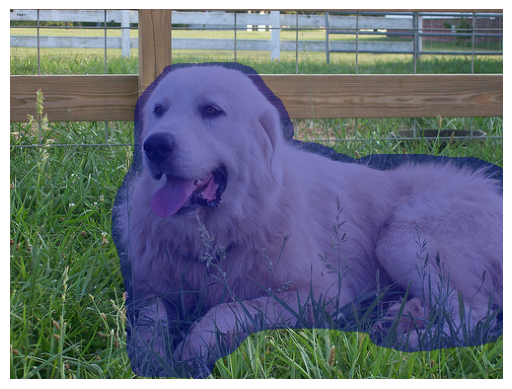

In [3]:
i = 0

image, (mask, cat) = train_dataset[i]
mask = utils.preprocess(mask)

visu.plot_mask(image, mask)

In [ ]:
n_segments=100
compactness=20


agg_func = aggregation.lab_mean_var_hist_agg


features, labels = utils.extract_super_features(train_dataset, n_segments, compactness, agg_func)
features, labels = utils.balance_data(features, labels)

In [5]:
logisticMask = models.SuperLogisticMask(agg_func=agg_func)
rdfMask = models.SuperSegment(RandomForestClassifier(10, max_depth=2), agg_func=agg_func)
densityMask = models.SuperDensityMask(agg_func=agg_func)

logisticMask.fit(features, labels)
rdfMask.fit(features, labels)
densityMask.fit(features, labels)

In [6]:
max_iter = 100
model = densityMask

ious = inference.sequential_segmentation(test_dataset, model, max_iter, trw=True)
print("Mean IoU:", ious.mean())

  0%|          | 0/100 [00:00<?, ?it/s]

Mean IoU: 0.4102467235872529


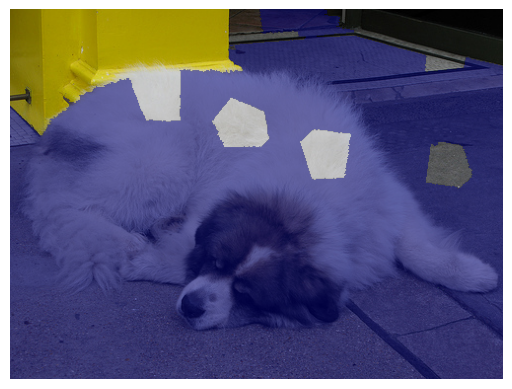

0.5077576514678326


In [7]:
i = 4
max_iter = 100

image, (mask, cat) = test_dataset[i]
mask = utils.preprocess(mask)
image = np.array(image)

predictions = model(image, max_iter, trw=True)
    
visu.plot_mask(image, predictions)
print(utils.IoU(mask, predictions))